<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/aliya's-LR/DMW_GA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score
)

# LOAD AND INSPEC

In [ ]:
from google.colab import drive
import csv # Import csv module for quoting options
# drive.mount('/content/drive')

# Load the dataset
filename = '/content/synthetic_data_cleaned_feature_engineered.csv'
# Added sep='|', engine='python', quotechar=None, and quoting=csv.QUOTE_NONE to correctly parse pipe-delimited data
df = pd.read_csv(filename, on_bad_lines='skip', sep='|', engine='python', quotechar=None, quoting=csv.QUOTE_NONE)

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")

✅ Data Loaded Successfully!
Shape: (1091, 13)


# DATA PREPROCESSING


✅ Features: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income', 'Occupation_Education', 'Occupation_Medical', 'Occupation_Other', 'Occupation_Real Estate', 'Occupation_Retired', 'Occupation_Service', 'Occupation_Student', 'Occupation_Tech', 'Occupation_Trade']
✅ Target distribution:
Default_Status
0    630
1    461
Name: count, dtype: int64
✅ Data Preprocessing Complete.
✅ Model Training Complete.

LOGISTIC REGRESSION MODEL PERFORMANCE
Accuracy:  0.8265
Recall:    0.7097 (Crucial for catching defaulters)
F1-Score:  0.7765 (Balance of Precision/Recall)
ROC-AUC:   0.8972

Top 5 Most Important Features:
- DTI_Ratio: 1.9516
- Risk_Flag: 1.7054
- Has_Asset: 0.3327
- Loan_Amount: 0.2471
- Credit_Score: 0.2355

Classification Report:

              precision    recall  f1-score   support

        Paid       0.81      0.91      0.86       126
     Default       0.86      0.71      0.78        93

    accuracy        

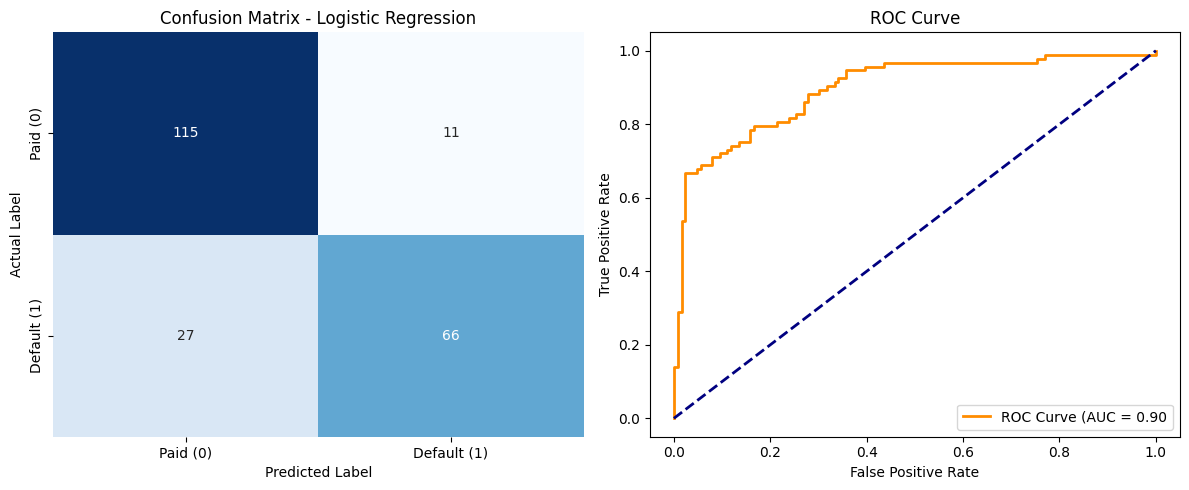


✅ Visualizations Generated.


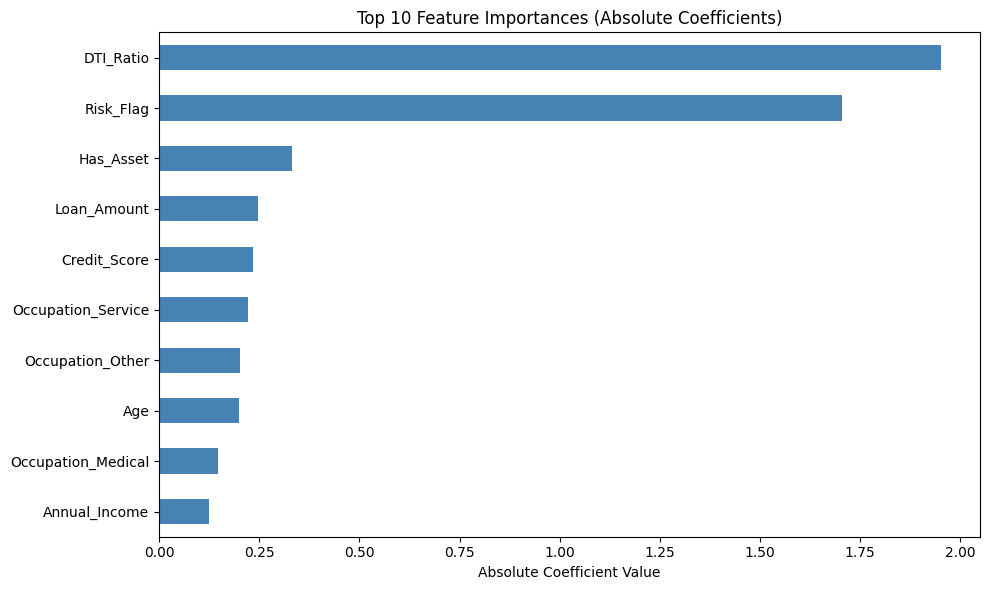


COEFFICIENT INTERPRETATION
Positive coefficients → Increase default probability
Negative coefficients → Decrease default probability

Top 5 Positive Predictors of Default:
               Feature  Coefficient
7            DTI_Ratio     1.951612
6            Risk_Flag     1.705394
2         Credit_Score     0.235483
0                  Age     0.200396
10  Occupation_Medical     0.146631

Top 5 Negative Predictors of Default:
               Feature  Coefficient
17    Occupation_Trade    -0.083994
11    Occupation_Other    -0.201903
14  Occupation_Service    -0.222424
3          Loan_Amount    -0.247055
5            Has_Asset    -0.332691


In [ ]:
# 2.1 Drop columns that are not useful for prediction
# Customer_ID is identifier, Loan_Officer_Note is text
df_clean = df.drop(columns=['Customer_ID', 'Loan_Officer_Note'])

# 2.2 One-Hot Encoding for 'Occupation' (categorical variable)
df_clean = pd.get_dummies(df_clean, columns=['Occupation'], drop_first=True)

# 2.3 Has_Asset is already 0/1, so no mapping needed
# But let's verify it's numeric
if df_clean['Has_Asset'].dtype == 'object':
    asset_mapping = {'Yes': 1, 'No': 0, 1: 1, 0: 0}
    df_clean['Has_Asset'] = df_clean['Has_Asset'].map(asset_mapping)

# Ensure no NaNs in target variable
df_clean.dropna(subset=['Default_Status'], inplace=True)

# 2.4 Define Features (X) and Target (y)
X = df_clean.drop(columns=['Default_Status'])
y = df_clean['Default_Status'].astype(int)

print(f"\n✅ Features: {X.columns.tolist()}")
print(f"✅ Target distribution:\n{y.value_counts()}")

# 2.5 Split Data into Training and Testing Sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2.6 Feature Scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessing Complete.")

# TRAIN

In [ ]:
# Initialize the Logistic Regression model
# max_iter increased to ensure convergence
# class_weight='balanced' helps with imbalanced data
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Helps with imbalanced classes
)

# Handle any potential NaNs in training data
nan_rows = np.isnan(X_train_scaled).any(axis=1)
if nan_rows.any():
    X_train_cleaned = X_train_scaled[~nan_rows]
    y_train_cleaned = y_train.iloc[~nan_rows]
    print(f"⚠️ Warning: Removed {np.sum(nan_rows)} rows containing NaN values from training data.")
else:
    X_train_cleaned = X_train_scaled
    y_train_cleaned = y_train

# Train the model
lr_model.fit(X_train_cleaned, y_train_cleaned)

print("✅ Model Training Complete.")

# EVALUATE TRAINING SET

In [ ]:
print("\n" + "="*50)
print("LOGISTIC REGRESSION MODEL PERFORMANCE ON TRAINING DATA")
print("="*50)

# Make predictions on the training set
y_train_pred = lr_model.predict(X_train_scaled)
y_train_prob = lr_model.predict_proba(X_train_scaled)[:, 1] # Probability for class 1 (Default)

# Calculate core metrics for training set
metric_train_accuracy = accuracy_score(y_train_cleaned, y_train_pred)
metric_train_precision = precision_score(y_train_cleaned, y_train_pred)
metric_train_recall = recall_score(y_train_cleaned, y_train_pred)
metric_train_f1 = f1_score(y_train_cleaned, y_train_pred)
metric_train_auc = roc_auc_score(y_train_cleaned, y_train_prob)

# Print detailed performance metrics
print(f"Accuracy:   {metric_train_accuracy:.4f} ({metric_train_accuracy:.2%})")
print(f"Precision:  {metric_train_precision:.4f} ({metric_train_precision:.2%})")
print(f"Recall:     {metric_train_recall:.4f} ({metric_train_recall:.2%})")
print(f"F1-Score:   {metric_train_f1:.4f}")
print(f"ROC-AUC:    {metric_train_auc:.4f}")

print("\n" + "-"*50)
print("CLASSIFICATION REPORT (TRAINING SET)")
print("-"*50)
print(classification_report(y_train_cleaned, y_train_pred, target_names=['Paid (0)', 'Default (1)']))



LOGISTIC REGRESSION MODEL PERFORMANCE ON TRAINING DATA
Accuracy:   0.8773 (87.73%)
Precision:  0.8967 (89.67%)
Recall:     0.8016 (80.16%)
F1-Score:   0.8465
ROC-AUC:    0.9061

--------------------------------------------------
CLASSIFICATION REPORT (TRAINING SET)
--------------------------------------------------
              precision    recall  f1-score   support

    Paid (0)       0.87      0.93      0.90       504
 Default (1)       0.90      0.80      0.85       368

    accuracy                           0.88       872
   macro avg       0.88      0.87      0.87       872
weighted avg       0.88      0.88      0.88       872

